# Lab 05: HOG-Based Industrial Defect Detection and Classification
**Dua e Zainab | FA34-BAI-027**

Pipeline: Image → Preprocessing → HOG → Classifier → Accept/Reject

In [ ]:
!pip -q install kagglehub scikit-image opencv-python-headless joblib

## Task 1: Load and inspect dataset

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Dataset path: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split
Total images: 1800
label
pitted_surface     300
crazing            300
scratches          300
rolled-in_scale    300
patches            300
inclusion          300
Name: count, dtype: int64


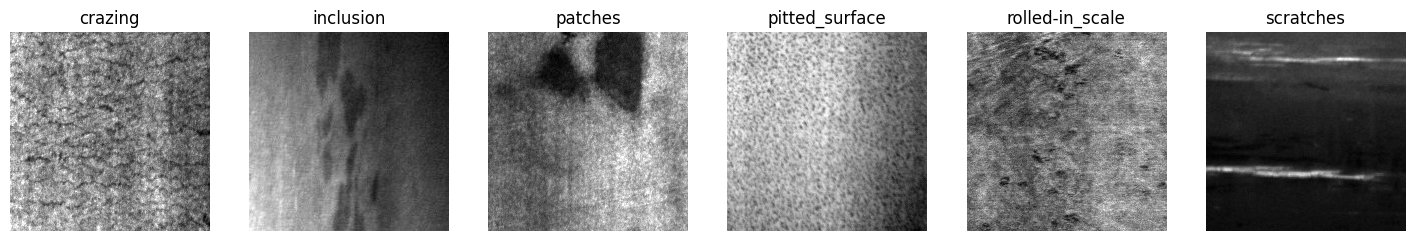

In [1]:
import os, re, glob, cv2, joblib, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import kagglehub
from joblib import Parallel, delayed
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")
SEED = 42
IMG_SIZE = 128

root = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")
print("Dataset path:", root)

files = [p for p in glob.glob(root + "/**/*", recursive=True)
         if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]

def label_of(p):
    name = os.path.splitext(os.path.basename(p))[0]
    return re.sub(r"[_-]?\d+$", "", name)     # crazing_12 -> crazing

df = pd.DataFrame({"path": files, "label": [label_of(p) for p in files]})
print("Total images:", len(df))
print(df["label"].value_counts())

# show one sample per class
classes = sorted(df["label"].unique())
fig, ax = plt.subplots(1, len(classes), figsize=(3*len(classes), 3))
for a, c in zip(np.atleast_1d(ax), classes):
    a.imshow(cv2.imread(df[df.label == c].path.iloc[0], 0), cmap="gray"); a.set_title(c); a.axis("off")
plt.show()

**Note on the dataset:** NEU-DET contains only 6 *defective* classes (crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches), with no normal images. So this notebook does the **advanced multi-class** formulation. Any predicted defect class → REJECT. If you add a folder of normal images (see optional cell), a `normal` class is added and ACCEPT works too.

In [2]:
# OPTIONAL: if you have normal / defect-free images, put them in /content/normal_images and re-run from the top
NORMAL_DIR = "/content/normal_images"
if os.path.isdir(NORMAL_DIR):
    nf = [p for p in glob.glob(NORMAL_DIR + "/*") if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    df = pd.concat([df, pd.DataFrame({"path": nf, "label": "normal"})], ignore_index=True)
    classes = sorted(df["label"].unique())
    print("Added normal images:", len(nf))
NORMAL_NAMES = {"normal", "non-defective"}

## Tasks 2-3: Resize + grayscale

In [3]:
def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)       # grayscale
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # common resolution

imgs = np.array(Parallel(n_jobs=-1)(delayed(preprocess)(p) for p in df.path))
y_names = df["label"].values
class_to_id = {c: i for i, c in enumerate(classes)}
y = np.array([class_to_id[c] for c in y_names])

idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=SEED)
Xtr_img, Xte_img, ytr, yte = imgs[idx_tr], imgs[idx_te], y[idx_tr], y[idx_te]
print("Train:", Xtr_img.shape, "Test:", Xte_img.shape)

Train: (1440, 128, 128) Test: (360, 128, 128)


## Tasks 4-5: HOG extraction + visualization

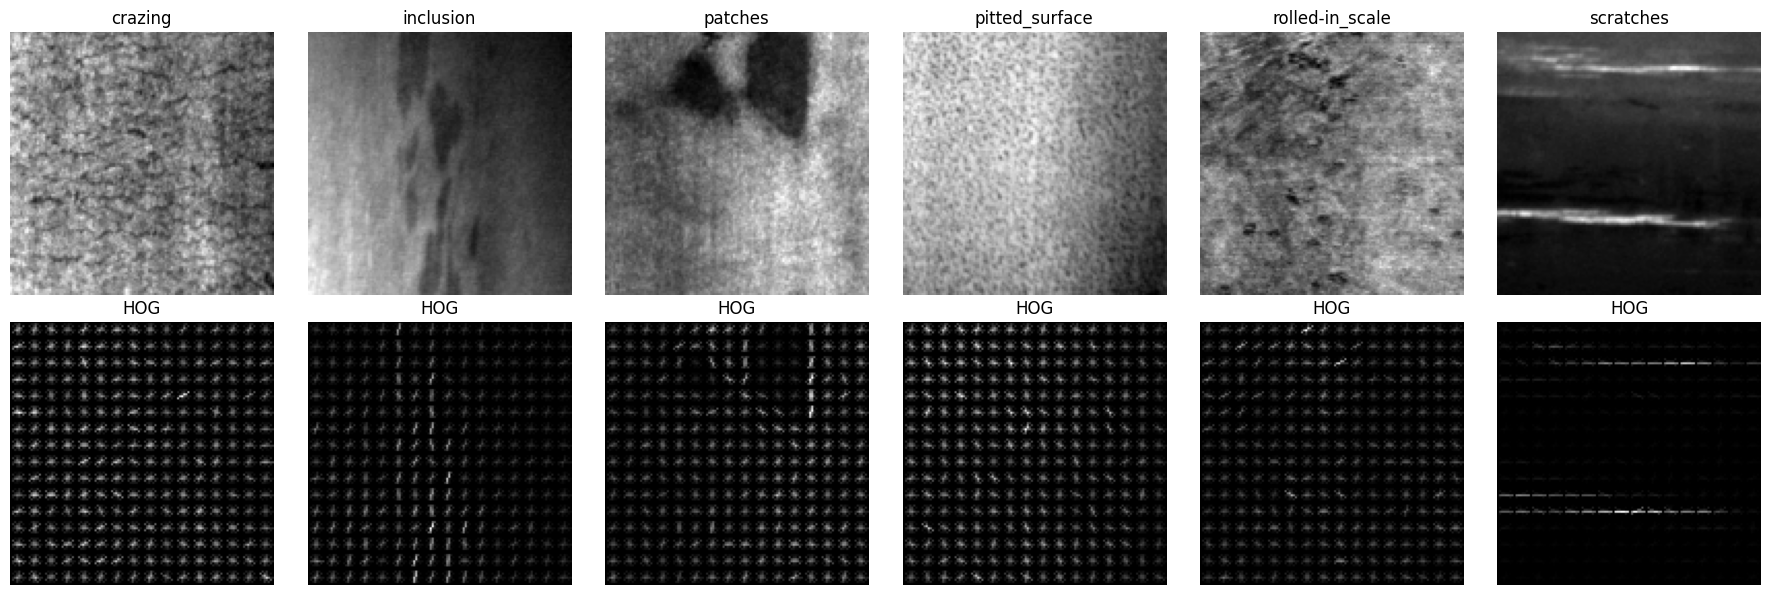

HOG feature length (8x8, 9 ori): 8100


In [4]:
def hog_feat(img, cell=8, ori=9):
    return hog(img, orientations=ori, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm="L2-Hys")

def extract(imgs, cell=8, ori=9):
    return np.array(Parallel(n_jobs=-1)(delayed(hog_feat)(im, cell, ori) for im in imgs))

fig, ax = plt.subplots(2, len(classes), figsize=(3*len(classes), 6))
for j, c in enumerate(classes):
    im = imgs[np.where(y == class_to_id[c])[0][0]]
    _, vis = hog(im, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    ax[0, j].imshow(im, cmap="gray"); ax[0, j].set_title(c); ax[0, j].axis("off")
    ax[1, j].imshow(vis, cmap="gray"); ax[1, j].set_title("HOG"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()
print("HOG feature length (8x8, 9 ori):", hog_feat(imgs[0]).shape[0])

## Tasks 6-10: SVM + second classifier, comparison, metrics

,Model,Accuracy,Precision,Recall,F1
0,SVM (linear),0.8500,0.8521,0.8500,0.8480
1,SVM (RBF),0.9000,0.9025,0.9000,0.8983
2,Random Forest,0.7694,0.7807,0.7694,0.7586
3,KNN,0.6667,0.6400,0.6667,0.6235


Best classifier at 8x8/9 ori: SVM (RBF)
                 precision    recall  f1-score   support

        crazing     0.8333    1.0000    0.9091        60
      inclusion     0.8788    0.9667    0.9206        60
        patches     0.8824    0.7500    0.8108        60
 pitted_surface     0.8571    0.8000    0.8276        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.9636    0.8833    0.9217        60

       accuracy                         0.9000       360
      macro avg     0.9025    0.9000    0.8983       360
   weighted avg     0.9025    0.9000    0.8983       360



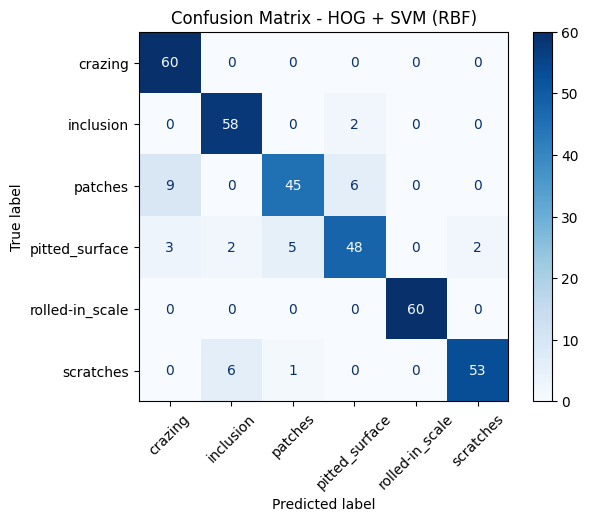

In [5]:
def metrics(yt, yp):
    return dict(Accuracy=accuracy_score(yt, yp),
                Precision=precision_score(yt, yp, average="macro", zero_division=0),
                Recall=recall_score(yt, yp, average="macro", zero_division=0),
                F1=f1_score(yt, yp, average="macro", zero_division=0))

models = {
    "SVM (linear)": lambda: SVC(kernel="linear", C=1, probability=True, random_state=SEED),
    "SVM (RBF)": lambda: SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=5),
}

Xtr = extract(Xtr_img, 8, 9); Xte = extract(Xte_img, 8, 9)
rows, fitted = [], {}
for name, mk in models.items():
    m = mk().fit(Xtr, ytr); fitted[name] = m
    rows.append({"Model": name, **metrics(yte, m.predict(Xte))})
res_models = pd.DataFrame(rows).round(4)
display(res_models)

best_name = res_models.sort_values("F1", ascending=False).iloc[0]["Model"]
print("Best classifier at 8x8/9 ori:", best_name)
yp = fitted[best_name].predict(Xte)
print(classification_report(yte, yp, target_names=classes, digits=4))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=classes).plot(xticks_rotation=45, cmap="Blues")
plt.title(f"Confusion Matrix - HOG + {best_name}"); plt.show()

## Task 11: HOG parameter study (cell size × orientations)

{'Cell': '4x4', 'Orient': 6, 'Features': 23064, 'Model': 'SVM (linear)', 'Accuracy': 0.8, 'Precision': 0.7986547542753843, 'Recall': 0.7999999999999999, 'F1': 0.7963834478961048}
{'Cell': '4x4', 'Orient': 6, 'Features': 23064, 'Model': 'Random Forest', 'Accuracy': 0.6194444444444445, 'Precision': 0.624174211064455, 'Recall': 0.6194444444444444, 'F1': 0.5970136479492737}
{'Cell': '4x4', 'Orient': 9, 'Features': 34596, 'Model': 'SVM (linear)', 'Accuracy': 0.7916666666666666, 'Precision': 0.7892121711302854, 'Recall': 0.7916666666666666, 'F1': 0.7864707214703625}
{'Cell': '4x4', 'Orient': 9, 'Features': 34596, 'Model': 'Random Forest', 'Accuracy': 0.625, 'Precision': 0.6195429336581022, 'Recall': 0.6250000000000001, 'F1': 0.5976804585573188}
{'Cell': '4x4', 'Orient': 12, 'Features': 46128, 'Model': 'SVM (linear)', 'Accuracy': 0.8388888888888889, 'Precision': 0.8406507075728286, 'Recall': 0.8388888888888889, 'F1': 0.8343529978787613}
{'Cell': '4x4', 'Orient': 12, 'Features': 46128, 'Model'

,Cell,Orient,Features,Model,Accuracy,Precision,Recall,F1
0,4x4,6,23064,SVM (linear),0.8000,0.7987,0.8000,0.7964
1,4x4,6,23064,Random Forest,0.6194,0.6242,0.6194,0.5970
2,4x4,9,34596,SVM (linear),0.7917,0.7892,0.7917,0.7865
3,4x4,9,34596,Random Forest,0.6250,0.6195,0.6250,0.5977
4,4x4,12,46128,SVM (linear),0.8389,0.8407,0.8389,0.8344
5,4x4,12,46128,Random Forest,0.6250,0.6241,0.6250,0.6088
6,8x8,6,5400,SVM (linear),0.8444,0.8457,0.8444,0.8427
7,8x8,6,5400,Random Forest,0.7972,0.8160,0.7972,0.7912
8,8x8,9,8100,SVM (linear),0.8500,0.8521,0.8500,0.8480
9,8x8,9,8100,Random Forest,0.7694,0.7807,0.7694,0.7586


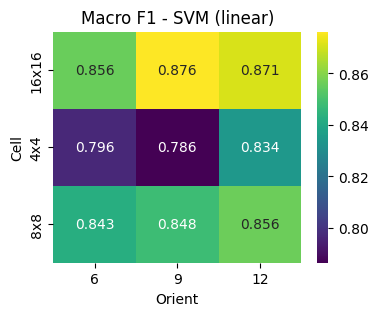

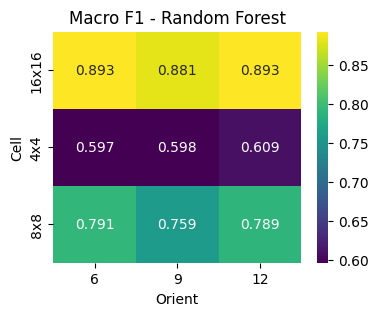

Best HOG config for SVM: 16 x 16 | 9 orientations


In [6]:
cells, oris = [4, 8, 16], [6, 9, 12]
rows = []
for c in cells:
    for o in oris:
        a, b = extract(Xtr_img, c, o), extract(Xte_img, c, o)
        for name in ["SVM (linear)", "Random Forest"]:
            m = models[name]().fit(a, ytr)
            r = metrics(yte, m.predict(b))
            rows.append({"Cell": f"{c}x{c}", "Orient": o, "Features": a.shape[1], "Model": name, **r})
            print(rows[-1])
res_hog = pd.DataFrame(rows).round(4)
display(res_hog)

for name in ["SVM (linear)", "Random Forest"]:
    pv = res_hog[res_hog.Model == name].pivot(index="Cell", columns="Orient", values="F1")
    plt.figure(figsize=(4, 3)); sns.heatmap(pv, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Macro F1 - {name}"); plt.show()

top = res_hog[res_hog.Model == "SVM (linear)"].sort_values("F1", ascending=False).iloc[0]
BEST_CELL, BEST_ORI = int(top["Cell"].split("x")[0]), int(top["Orient"])
print("Best HOG config for SVM:", BEST_CELL, "x", BEST_CELL, "|", BEST_ORI, "orientations")

## Final models with best HOG config

,Model,Accuracy,Precision,Recall,F1
0,HOG + SVM,0.8778,0.8791,0.8778,0.8762
1,HOG + Random Forest,0.8833,0.8918,0.8833,0.8812


                 precision    recall  f1-score   support

        crazing     0.8615    0.9333    0.8960        60
      inclusion     0.8406    0.9667    0.8992        60
        patches     0.8039    0.6833    0.7387        60
 pitted_surface     0.7869    0.8000    0.7934        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.9815    0.8833    0.9298        60

       accuracy                         0.8778       360
      macro avg     0.8791    0.8778    0.8762       360
   weighted avg     0.8791    0.8778    0.8762       360



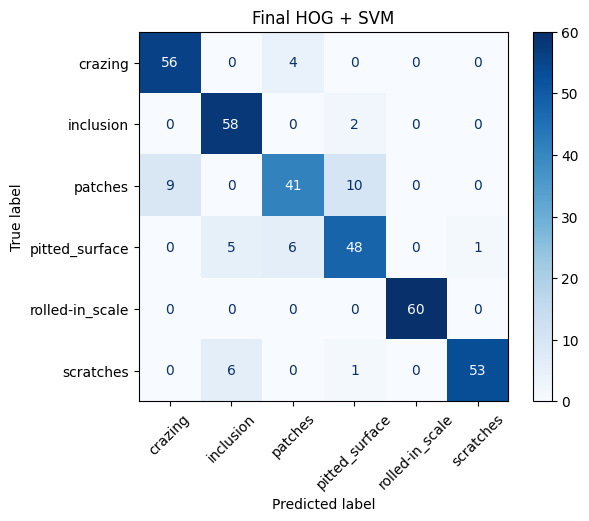

In [7]:
Xtr = extract(Xtr_img, BEST_CELL, BEST_ORI); Xte = extract(Xte_img, BEST_CELL, BEST_ORI)
svm = models["SVM (linear)"]().fit(Xtr, ytr)
rf = models["Random Forest"]().fit(Xtr, ytr)
final = pd.DataFrame([{"Model": "HOG + SVM", **metrics(yte, svm.predict(Xte))},
                      {"Model": "HOG + Random Forest", **metrics(yte, rf.predict(Xte))}]).round(4)
display(final)
print(classification_report(yte, svm.predict(Xte), target_names=classes, digits=4))
ConfusionMatrixDisplay(confusion_matrix(yte, svm.predict(Xte)), display_labels=classes).plot(xticks_rotation=45, cmap="Blues")
plt.title("Final HOG + SVM"); plt.show()

## Task 12: Robustness experiment

,Condition,Model,Accuracy,F1,dAcc,dF1
0,Clean,SVM,0.8778,0.8762,0.0000,0.0000
1,Clean,Random Forest,0.8833,0.8812,0.0000,0.0000
2,Brightness +40,SVM,0.7861,0.7747,-0.0917,-0.1015
3,Brightness +40,Random Forest,0.8139,0.8078,-0.0694,-0.0733
4,Brightness -40,SVM,0.8750,0.8732,-0.0028,-0.0030
5,Brightness -40,Random Forest,0.8944,0.8928,0.0111,0.0116
6,Gaussian noise s=10,SVM,0.3417,0.2757,-0.5361,-0.6005
7,Gaussian noise s=10,Random Forest,0.2306,0.1458,-0.6528,-0.7353
8,Gaussian noise s=25,SVM,0.2250,0.1418,-0.6528,-0.7344
9,Gaussian noise s=25,Random Forest,0.1972,0.1027,-0.6861,-0.7785


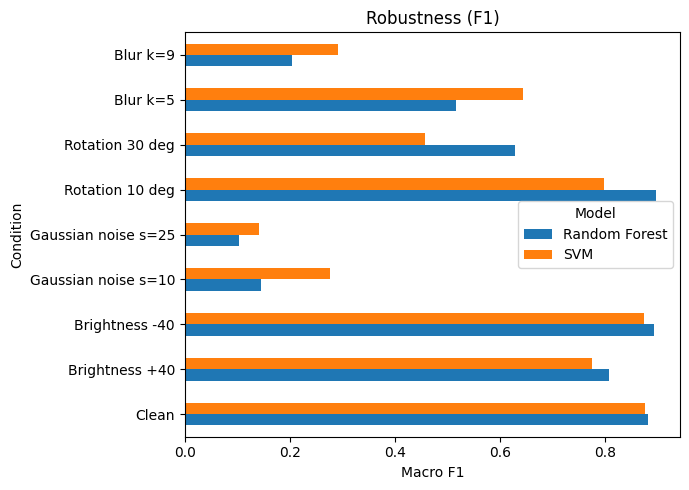

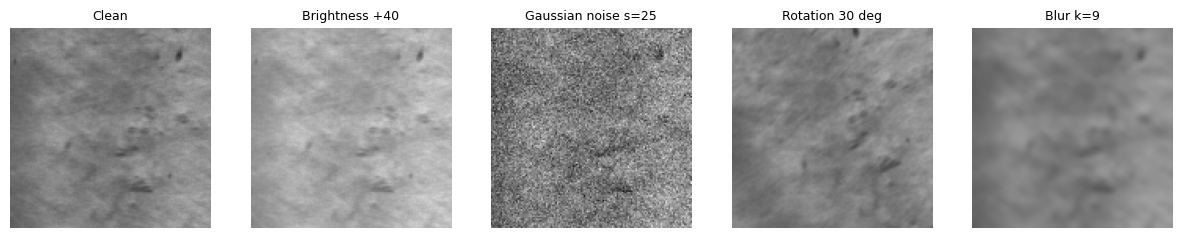

In [8]:
def brightness(im, beta):  return np.clip(im.astype(np.int16) + beta, 0, 255).astype(np.uint8)
def noise(im, sigma):      return np.clip(im + np.random.default_rng(SEED).normal(0, sigma, im.shape), 0, 255).astype(np.uint8)
def rotate(im, ang):
    M = cv2.getRotationMatrix2D((im.shape[1]/2, im.shape[0]/2), ang, 1.0)
    return cv2.warpAffine(im, M, im.shape[::-1], borderMode=cv2.BORDER_REFLECT)
def blur(im, k):           return cv2.GaussianBlur(im, (k, k), 0)

tests = {
    "Clean": lambda im: im,
    "Brightness +40": lambda im: brightness(im, 40),
    "Brightness -40": lambda im: brightness(im, -40),
    "Gaussian noise s=10": lambda im: noise(im, 10),
    "Gaussian noise s=25": lambda im: noise(im, 25),
    "Rotation 10 deg": lambda im: rotate(im, 10),
    "Rotation 30 deg": lambda im: rotate(im, 30),
    "Blur k=5": lambda im: blur(im, 5),
    "Blur k=9": lambda im: blur(im, 9),
}
rows = []
for name, f in tests.items():
    Xp = extract(np.array([f(im) for im in Xte_img]), BEST_CELL, BEST_ORI)
    for mname, m in [("SVM", svm), ("Random Forest", rf)]:
        r = metrics(yte, m.predict(Xp)); rows.append({"Condition": name, "Model": mname, "Accuracy": r["Accuracy"], "F1": r["F1"]})
rob = pd.DataFrame(rows)
for mname in ["SVM", "Random Forest"]:
    base = rob[(rob.Condition == "Clean") & (rob.Model == mname)].iloc[0]
    sel = rob.Model == mname
    rob.loc[sel, "dAcc"] = rob.loc[sel, "Accuracy"] - base["Accuracy"]
    rob.loc[sel, "dF1"] = rob.loc[sel, "F1"] - base["F1"]
rob = rob.round(4); display(rob)

p = rob.pivot(index="Condition", columns="Model", values="F1").loc[list(tests)]
p.plot(kind="barh", figsize=(7, 5)); plt.xlabel("Macro F1"); plt.title("Robustness (F1)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, (n, f) in zip(ax, [(k, tests[k]) for k in ["Clean", "Brightness +40", "Gaussian noise s=25", "Rotation 30 deg", "Blur k=9"]]):
    a.imshow(f(Xte_img[0]), cmap="gray", vmin=0, vmax=255); a.set_title(n, fontsize=9); a.axis("off")
plt.show()

## Task 13: Quality-control decision module

True class: crazing
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (crazing)
Confidence: 91.7%
Action: REJECT PRODUCT



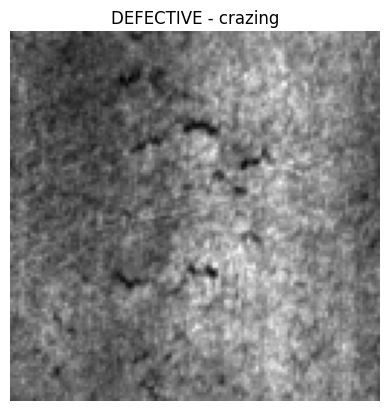

True class: patches
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (pitted_surface)
Confidence: 90.6%
Action: REJECT PRODUCT



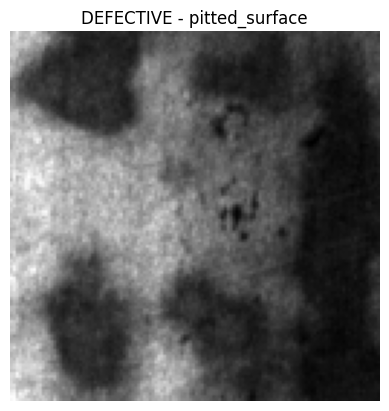

True class: inclusion
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (inclusion)
Confidence: 66.7%
Action: REJECT PRODUCT



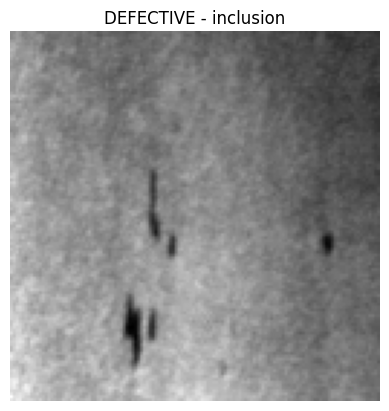

True class: rolled-in_scale
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (rolled-in_scale)
Confidence: 99.7%
Action: REJECT PRODUCT



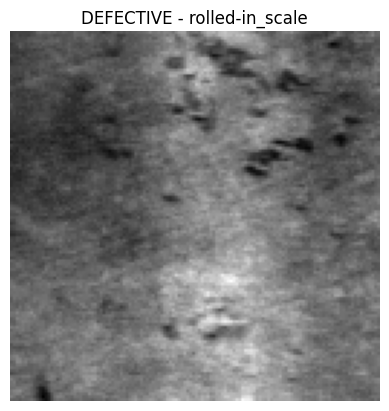

In [9]:
CONF_THRESHOLD = 0.50   # below this the product is also rejected (flag for manual review)

def inspect_product(source, model=svm, show=True):
    im = source if isinstance(source, np.ndarray) else cv2.imread(source, cv2.IMREAD_GRAYSCALE)
    if im.ndim == 3: im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im = cv2.resize(im, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    prob = model.predict_proba(hog_feat(im, BEST_CELL, BEST_ORI).reshape(1, -1))[0]
    k = int(np.argmax(prob)); label = classes[k]
    if label in NORMAL_NAMES:
        pred, conf, action = "NON-DEFECTIVE", prob[k], "ACCEPT PRODUCT"
    else:
        pred, conf, action = "DEFECTIVE", prob[k], "REJECT PRODUCT"
    if conf < CONF_THRESHOLD: action = "REJECT PRODUCT (LOW CONFIDENCE - MANUAL REVIEW)"
    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {pred}" + (f" ({label})" if pred == "DEFECTIVE" else ""))
    print(f"Confidence: {conf*100:.1f}%")
    print(f"Action: {action}\n")
    if show: plt.imshow(im, cmap="gray"); plt.title(f"{pred} - {label}"); plt.axis("off"); plt.show()
    return pred, conf, action

for i in np.random.default_rng(1).choice(len(idx_te), 4, replace=False):
    print("True class:", classes[yte[i]]); inspect_product(df.path.iloc[idx_te[i]])

## Save model + bonus real-time script

In [10]:
joblib.dump({"model": svm, "classes": classes, "cell": BEST_CELL, "ori": BEST_ORI, "size": IMG_SIZE,
             "normal_names": list(NORMAL_NAMES)}, "/content/hog_defect_model.joblib")

script = """
import cv2, joblib, numpy as np
from skimage.feature import hog
d = joblib.load("hog_defect_model.joblib")
m, classes, cell, ori, size = d["model"], d["classes"], d["cell"], d["ori"], d["size"]
cap = cv2.VideoCapture(0)   # or a video file path
while True:
    ok, frame = cap.read()
    if not ok: break
    h, w = frame.shape[:2]; s = min(h, w) // 2
    roi = frame[h//2 - s//2: h//2 + s//2, w//2 - s//2: w//2 + s//2]
    g = cv2.resize(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY), (size, size))
    f = hog(g, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(2, 2), block_norm="L2-Hys")
    p = m.predict_proba(f.reshape(1, -1))[0]; k = int(np.argmax(p))
    ok_flag = classes[k] in d["normal_names"]
    txt = "PASS" if ok_flag else "DEFECTIVE: " + classes[k]
    col = (0, 200, 0) if ok_flag else (0, 0, 255)
    cv2.rectangle(frame, (w//2 - s//2, h//2 - s//2), (w//2 + s//2, h//2 + s//2), col, 2)
    cv2.putText(frame, f"{txt} ({p[k]*100:.0f}%)", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, col, 2)
    cv2.imshow("HOG Inspection", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"): break
cap.release(); cv2.destroyAllWindows()
"""
open("/content/realtime_hog.py", "w").write(script)
print("Saved: /content/hog_defect_model.joblib and /content/realtime_hog.py")
print("Run realtime_hog.py locally (webcam does not work in plain Colab). Download both files from the Colab file panel.")

Saved: /content/hog_defect_model.joblib and /content/realtime_hog.py
Run realtime_hog.py locally (webcam does not work in plain Colab). Download both files from the Colab file panel.
